In [3]:
%load_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import pandas as pd
from pgmpy.estimators import BayesianEstimator

from src.effects import DE, IE, SE, TE, TV
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.visualisation.graph import visualize_sfm

/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
filepath = "./data/processed/adult.csv"
df = pd.read_csv(filepath)

# Group the hours-per-week into categories
bins = [0, 20, 40, 60, 80, float("inf")]
labels = ["0-20", "21-40", "41-60", "61-80", "80+"]
df["hours-per-week"] = pd.cut(
    df["hours-per-week"], bins=bins, labels=labels, right=False
)

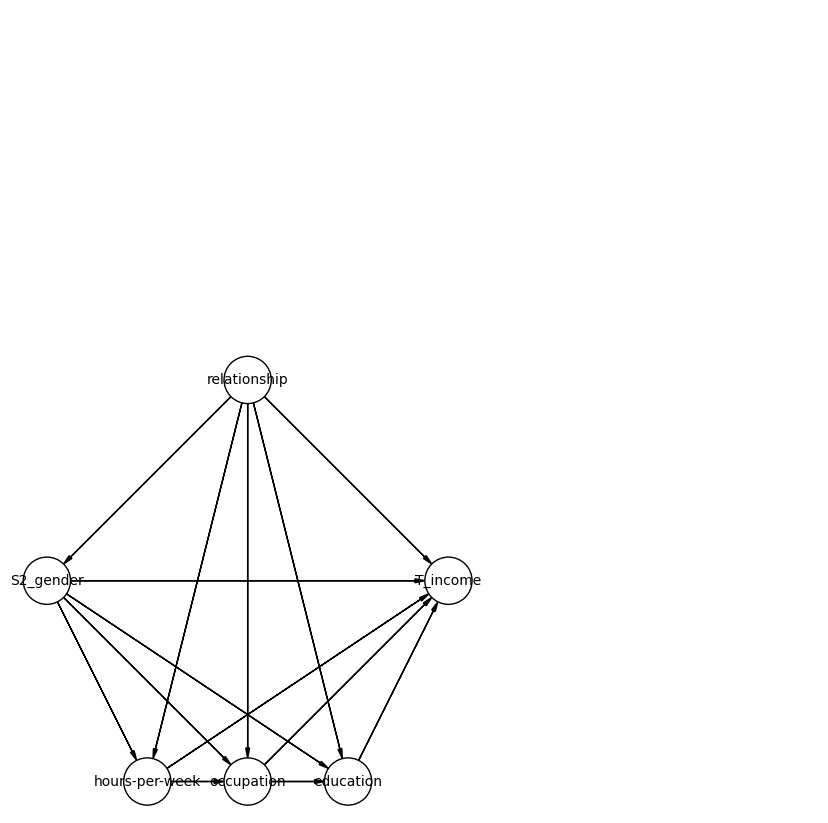

In [5]:
private_attr = "S2_gender"

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr="T_income",
    confounder_attrs=["relationship"],
    mediator_attrs=["hours-per-week", "occupation", "education"],
    # mediator_attrs=["hours-per-week"],
    sorted_mediators=True,
)

# sfm_markovian = build_sfm(
#     sensitive_attr="S2_gender",
#     outcome_attr="T_income",
#     confounder_attrs=["relationship"],
#     mediator_attrs=["hours-per-week"],
#     latents=[
#         ("UX", ["S2_gender"]),
#         ("UY", ["T_income"]),
#         ("UZ", ["relationship"]),
#         ("UW", ["hours-per-week"]),
#     ],
# )

visualize_sfm(sfm)


In [6]:
bn = fit_discrete_bayesian_model(
    sfm,
    df,
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

# bn_markovian = fit_discrete_bayesian_model(
#     sfm_markovian,
#     df,
#     estimator_instance=(
#         ExpectationMaximization,
#         {
#             "latent_card": {
#                 "UX": 4,
#                 "UY": 16,
#                 "UZ": 2,
#                 "UW": 8,
#             },
#             "seed": 42,
#         },
#     ),
# )

assert bn.check_model()

2026-03-09 11:43:02.373 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'N', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'N', 'capital-loss': 'N', 'hours-per-week': 'O', 'native-country': 'C', 'T_income': 'C'}


Classical effect computations for binary sensitive attribute.

In [7]:
tv = TV(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
tot_eff = TE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
# total_effect_scm(bn, ("T_income", "<=50K"), "S2_gender", x0="Male", x1="Female")

se_male = SE(bn, ("T_income", "<=50K"), "S2_gender", "Male")
se_female = SE(bn, ("T_income", "<=50K"), "S2_gender", "Female")

# nde_mf = DE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
nie_fm = IE(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Female",
    "Male",
)

# print(tot_eff)
# print(se_male)
# print(se_female)
# print(tv)
# print(tot_eff + (se_female - se_male))
# print(nde_mf, nie_mf)

2026-03-09 11:43:03.233 | DEBUG    | src.effects:total_variation:249 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-09 11:43:03.241 | DEBUG    | src.effects:spurious_effect:196 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-09 11:43:03.245 | DEBUG    | src.effects:spurious_effect:196 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female
2026-03-09 11:43:03.249 | DEBUG    | src.effects:natural_indirect_effect:424 - Computing natural direct effect for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Male


In [36]:
from pymc.dims.math import second
from mpmath import sec
from src.effects import set_specific_indirect_effect

set_specific_indirect_effect(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Male",
    "Female",
    [
        "hours-per-week",
    ],
    ["occupation", "education"],
)

2026-03-09 11:41:21.466 | DEBUG    | src.effects:set_specific_indirect_effect:1213 - Computing set-specific indirect effect for
            target=('T_income', '<=50K'),
            private_baseline=Male,
            private_mod=Female,
            first_mediator_partition=['hours-per-week'],
            second_mediator_partition=['occupation', 'education'],
            ordered_mediators=['hours-per-week', 'occupation', 'education']


array([ 0.00785035, -0.00785035])

In [37]:
from src.effects import decompose_indirect_effect

decompose_indirect_effect(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Female",
    "Male",
)

2026-03-09 11:41:29.164 | DEBUG    | src.effects:set_specific_indirect_effect:1213 - Computing set-specific indirect effect for
            target=('T_income', '<=50K'),
            private_baseline=Female,
            private_mod=Male,
            first_mediator_partition=[],
            second_mediator_partition=['occupation', 'education'],
            ordered_mediators=['hours-per-week', 'occupation', 'education']


Computing contribution of mediator hours-per-week with W_prec=[] and W_succ=['occupation', 'education']


2026-03-09 11:41:32.574 | DEBUG    | src.effects:set_specific_indirect_effect:1213 - Computing set-specific indirect effect for
            target=('T_income', '<=50K'),
            private_baseline=Female,
            private_mod=Male,
            first_mediator_partition=['hours-per-week'],
            second_mediator_partition=['education'],
            ordered_mediators=['hours-per-week', 'occupation', 'education']


Computing contribution of mediator occupation with W_prec=['hours-per-week'] and W_succ=['education']


2026-03-09 11:41:35.890 | DEBUG    | src.effects:set_specific_indirect_effect:1213 - Computing set-specific indirect effect for
            target=('T_income', '<=50K'),
            private_baseline=Female,
            private_mod=Male,
            first_mediator_partition=['hours-per-week', 'occupation'],
            second_mediator_partition=[],
            ordered_mediators=['hours-per-week', 'occupation', 'education']


Computing contribution of mediator education with W_prec=['hours-per-week', 'occupation'] and W_succ=[]


{'hours-per-week': array([-0.03400584,  0.03400584]),
 'occupation': array([-0.01148326,  0.01148326]),
 'education': array([ 0.03770022, -0.03770022])}

In [10]:
-0.03400584-0.011483260

-0.045489100000000005

In [8]:
nie_fm

np.float64(-0.1587742234615911)

In [110]:
from src.effects import (
    natural_direct_effect_scm,
    natural_indirect_effect,
    natural_indirect_effect_scm,
)

a = natural_direct_effect_scm(
    bn, ("T_income", "<=50K"), "S2_gender", x0="Male", x1="Female"
)

b = natural_indirect_effect_scm(
    bn, ("T_income", "<=50K"), "S2_gender", x0="Male", x1="Female"
)

NotImplementedError: This SCM implementation currently assumes exactly one mediator.

In [71]:
a, b

(np.float64(0.13639406710373703), np.float64(-0.016254758059891516))

Here we consider more than two states.

In [16]:
# from src.effects import (
#     categorical_natural_direct_effect,
#     categorical_natural_indirect_effect,
#     categorical_total_effect,
#     categorical_total_variation,
# )

# private_states = bn.get_cpds(private_attr).state_names[private_attr]
# protected_states = ["Black"]
# unprotected_states = [s for s in private_states if s not in protected_states]

# res_te = categorical_total_effect(
#     bn,
#     ("T_income", "<=50K"),
#     private_attr,
#     protected_states,
#     unprotected_states,
# )


# res_tv = categorical_total_variation(
#     bn,
#     ("T_income", "<=50K"),
#     private_attr,
#     protected_states,
#     unprotected_states,
# )

# res_nde = categorical_natural_direct_effect(
#     bn, ("T_income", "<=50K"), private_attr, protected_states, unprotected_states
# )

# res_nie = categorical_natural_indirect_effect(
#     bn, ("T_income", "<=50K"), private_attr, protected_states, unprotected_states
# )

If dealing with ordinal variables then simply pass the ordered list for the partitions to both parameters. 

In [19]:
from src.effects import (
    categorical_natural_direct_effect,
    categorical_natural_indirect_effect,
    categorical_total_effect,
    categorical_total_variation,
)

private_states = bn.get_cpds(private_attr).state_names[private_attr]
res_te = categorical_total_effect(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    private_states,
    private_states,
)


res_tv = categorical_total_variation(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    private_states,
    private_states,
)

res_nde = categorical_natural_direct_effect(
    bn, ("T_income", "<=50K"), private_attr, private_states, private_states
)

res_nie = categorical_natural_indirect_effect(
    bn, ("T_income", "<=50K"), private_attr, private_states, private_states
)

2026-03-08 23:27:15.504 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Female
2026-03-08 23:27:15.505 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Male
2026-03-08 23:27:15.506 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-08 23:27:15.507 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Male
2026-03-08 23:27:15.508 | DEBUG    | src.effects:natural_direct_effect:32 - Computing natural direct effect for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Female
2026-03-08 23:27:15.742 | DEBUG    | src.effects:natural_direct_effect:32 - Computing natural direct effect for target=('T

In [21]:
from src.effects import spurious_effect2

spurious_eff = spurious_effect2(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    "Male",
    "Female",
    ["relationship", "occupation"],
    decompose=True,
)

2026-03-08 23:27:25.156 | DEBUG    | src.effects:spurious_effect2:575 - Computing SE for target=('T_income', '<=50K'), cause=Male->Female. Confounder order: ['relationship', 'occupation']


In [22]:
spurious_eff

{'SE_relationship': np.float64(0.1721958586060206),
 'SE_occupation': np.float64(-0.0019914901189600487),
 'Total SE': np.float64(0.17020436848706055)}

In [11]:
se_male

np.float64(-0.052267965181285736)